In [1]:
import os
import deeptile
import matplotlib.pyplot as plt
import numpy as np
# from deeptile.extensions import stitch
# from tifffile import TiffFile
import tifffile
import dask.array as da
import utils
import skimage as ski

# import extract_features
import pandas as pd
from collections import defaultdict
from extract_features import features_basic, foci_features, feature_table, neighbor_measurements
from scipy import ndimage as ndi
import time

In [2]:
import importlib
import extract_features
importlib.reload(utils)
importlib.reload(extract_features)
from extract_features import features_basic, foci_features, feature_table, neighbor_measurements

In [ ]:
root = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/"
results_folder = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/"
# img_name = 'o8p_day18_s22.tif'
# img_name = 'o8p_day18.vsi'
# img_name = "o8p_day24_s12.ome.tif"

img_name = "o8p_day24_s12.ome.tif"
img_path = os.path.join(root, img_name)
with tifffile.TiffFile(img_path) as tif:
    dt_nuclei = deeptile.load(tif.pages[0].asarray())
    dt_foci = deeptile.load(tif.pages[1].asarray())
    img_dtype = tif.pages[0].dtype
mask_cyto = da.from_array(tifffile.imread("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_cytoplasm_mask.tif/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_cytoplasm_mask.tif"))

In [3]:
img_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12.ome.tif"
mask_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_cytoplasm_mask.tif"
y0 = 4000
x0 = 10000

# cells = da.from_array(tifffile.imread("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/reconcile_cyto_mask2.tif"))
# nucleus = da.from_array(tifffile.imread("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/reconcile_nuclei_mask2.tif"))
cyto_mask = da.from_array(tifffile.imread(mask_path))[y0:y0+4000, x0:x0+8400]
img = da.from_array(tifffile.imread(img_path))[:,y0:y0+4000, x0:x0+8400]

In [7]:
cyto_mask.max().compute()

np.uint16(488)

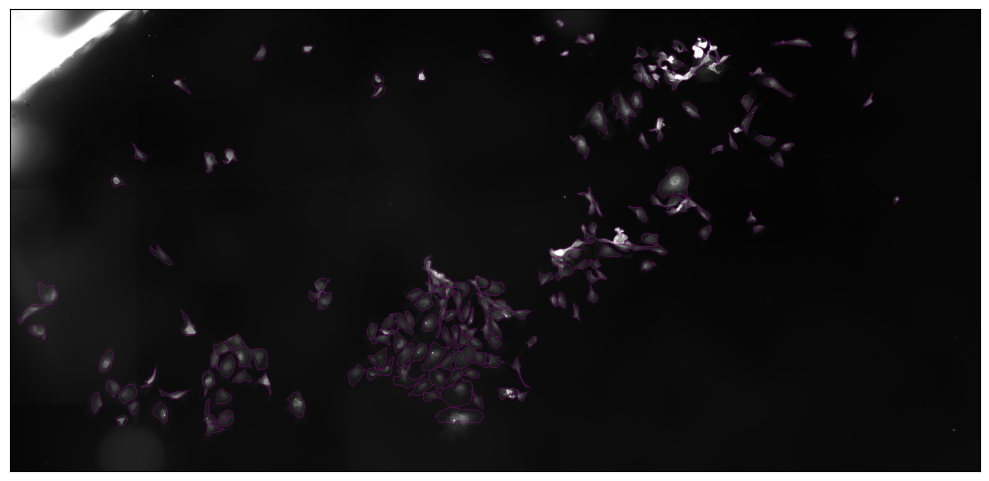

In [8]:
# fig, ax = plt.subplots(ncols=2,figsize=(20,10))
fig, ax = plt.subplots(figsize=(10,10))

# ax[0].imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(img[0], in_range=(0,4000)), nuclei, color=(1,0,0), mode='thick'), cells, color=(1,0,1)))
# ax[1].imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(img_log[1], nuclei, color=(1,0,0), mode='thick'), cells, color=(1,0,1)), cmap='gray')


# # # ax[1].imshow(ski.color.label2rgb(mask))
# # # ax[1].set_yticks([])
# # # ax[1].set_xticks([])
# # # plt.tight_layout()


# # # # #img2 = da.from_zarr(tifffile.imread(img_path, aszarr=True))[1,y0:y1,y0:y1]

# # # cy5 = da.from_zarr(tifffile.imread(img_path, aszarr=True))[1,y0:y1,y0:y1]
ax.imshow(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(img[1], in_range=(0,4000)), cyto_mask.compute(), color=(1,0,1), mode='thick'), cmap='gray')
#ax.imshow(masks_cyto[9,17], cmap='gray')


# ax[0].imshow(img_tiles[9,7][0], cmap='gray')
# ax[1].imshow(img_tiles[9,7][1], cmap='gray')


ax.set_yticks([])
ax.set_xticks([])
# ax[0].set_yticks([])
# ax[0].set_xticks([])
# ax[1].set_yticks([])
# ax[1].set_xticks([])

plt.tight_layout()

In [4]:
# Configure
tile_size = (2048, 2048)
overlap = (0.1, 0.1)
# Get nuceli tiles
# tiles_nuclei = dt_nuclei.get_tiles(tile_size, overlap)
# tiles_nuclei = tiles_nuclei.pad()
# Get foci tiles
tiles_foci = dt_foci.get_tiles(tile_size, overlap)
import_masks_nuclei = tiles_foci.import_data(mask_nuclei, "image").unpad() # need to unpad, pad bc bug in package code
# # Individual tile
# tiles_nuclei[0, 0]
# tiles_foci[0, 0]

In [5]:
# # Segment tiles and stitch
# start_cellpose = time.time()
# model_parameters = {'gpu': True}
# eval_parameters = {'diameter': 60}
# cellpose = utils.cellpose_segmentation(model_parameters, eval_parameters)

# masks_nuclei = cellpose(tiles_nuclei)
# mask_nuclei = stitch.stitch_masks(masks_nuclei)

# finish_segment_nuclei = time.time()

# # save mask
# nuclei_mask_file = "".join([img_name.split(".")[0], "_nuclei_mask.tif"])
# tifffile.imwrite(os.path.join(results_folder, nuclei_mask_file), mask_nuclei.astype(img_dtype))
# save_nuclei_mask = time.time()

In [6]:
# mask_file = "".join([img_path.split(".")[0], "_MASK.tif"])
# nuclei_mask_fromTif = da.from_array(tifffile.imread(mask_file))
# img_foci = da.from_array(tifffile.imread(img_path))[1]
# #labeled_nuclei_fromtif = ski.measure.label(nuclei_mask_fromTif)
# save mask
# mask_file = "".join([img_path.split(".")[0], "_MASK.tif"])
# img_dtype = tifffile.TiffFile(img_path).pages[0].dtype
# tifffile.imwrite(mask_file, mask_nuclei.astype(img_dtype))

In [7]:
# # Show the stitched mask
# fig, ax = plt.subplots(figsize=(20, 20))
# ax.imshow(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(dt_foci.image, in_range=(0,7000)), mask_nuclei, color=(1,0,1), mode="thick"), cmap='gray')
# # ski.exposure.rescale_intensity(nucleiTile,in_range = (256, 12000))

In [8]:
# num_nuclei = {"cellprob threshold 1": 253, "cellprob threshold 1.5": 223}

In [9]:
# # read in foci channel, make tiles
# with tifffile.TiffFile(img_path) as tif:
#     dt_foci = deeptile.load(tif.pages[1].asarray())

# tiles_foci = dt_foci.get_tiles(tile_size, overlap)
# tiles_foci = tiles_foci.pad()

In [10]:
## find foci
#importlib.reload(utils)
## make tiled nuclei mask with same profile as tiled foci
start_seg_foci = time.time()

# segment foci and stitch
kwargs = {"radius":2, "threshold":25, "min_distance":1, "regions":import_masks_nuclei, "remove_border_foci":False}
masks_foci = utils.segment_foci_tiled(tiles_foci, **kwargs)
mask_foci = stitch.stitch_masks(masks_foci)

finish_seg_foci = time.time()

# save mask
foci_mask_file = "".join([img_name.split(".")[0], "_foci_mask.tif"])
tifffile.imwrite(os.path.join(results_folder, foci_mask_file), mask_foci.astype(img_dtype))

# # save mask
# mask_file = "".join([img_path.split(".")[0], "_FOCI_MASK.tif"])
# img_dtype = tifffile.TiffFile(img_path).pages[0].dtype
# tifffile.imwrite(mask_file, mask_nuclei.astype(img_dtype))

In [11]:
# # Show the stitched mask
# fig, ax = plt.subplots(figsize=(20, 20))
# #ax[0].imshow(ski.color.label2rgb(foci_mask))
# #ax[0].imshow(ski.exposure.rescale_intensity(dt.image, in_range=(256,3000)), cmap='gray')
# ax.imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(dt_foci.image, in_range=(0,3000)), mask_foci), mask_nuclei, color=(1,0,1)), cmap='gray')

In [ ]:
img_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12.ome.tif"
foci_mask_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_foci_mask.tif"
y0 = 4000
x0 = 10000

cells = da.from_array(tifffile.imread("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/reconcile_cyto_mask2.tif"))
nucleus = da.from_array(tifffile.imread("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/reconcile_nuclei_mask2.tif"))
foci = da.from_array(tifffile.imread(foci_mask_path))[y0:y0+4000, x0:x0+8400]
img = da.from_zarr(tifffile.imread(img_path, aszarr=True))[:,y0:y0+4000, x0:x0+8400]

In [4]:
start_feature_extract = time.time()

dfs = []
dfs.append(
    feature_table(nucleus, features_basic, img[0])
    .set_index("label")
    .add_prefix("nucleus_")
)

dfs.append(
    feature_table(cells, features_basic, img[1])
    .set_index("label")
    .add_prefix("cells_")
)

dfs.append(
    feature_table(nucleus, foci_features, foci)
    .set_index("label")
)

dfs.append(
    neighbor_measurements(nucleus, distances=[1])
    .set_index("label")
    .add_prefix("nucleus_")
)

dfs.append(
    neighbor_measurements(cells, distances=[1])
    .set_index("label")
    .add_prefix("cells_")
)

finish_feature_extract = time.time()

results_fullslide = pd.concat(dfs, axis=1, join="outer", sort=False).reset_index().set_index("label", drop=True)
results_fullslide.to_csv("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/cells_nucleus_results2.csv")


/Users/hannahbolen/Desktop/image_analysis/whole_slide/current/extract_features.py:132: RuntimeWarning: invalid value encountered in scalar divide
  percent_touching = (outline_mask & dilated_neighbors).sum() / outline_mask.sum()
/Users/hannahbolen/Desktop/image_analysis/whole_slide/current/extract_features.py:132: RuntimeWarning: invalid value encountered in scalar divide
  percent_touching = (outline_mask & dilated_neighbors).sum() / outline_mask.sum()


In [3]:
nucleus = da.from_array(tifffile.imread("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/reconcile_nuclei_mask.tif"))

In [10]:
from cp_measure.multimask import measureobjectneighbors

In [11]:
results = measureobjectneighbors.measureobjectneighbors(nucleus.compute(), nucleus.compute())
df = pd.DataFrame(results)

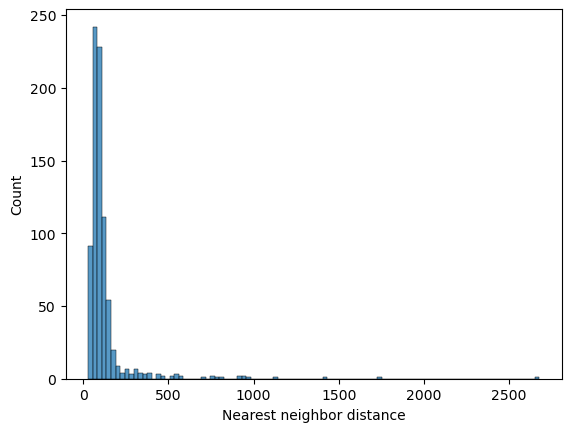

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    df["Neighbors_SecondClosestDistance_Expanded"],
    bins=100
)

plt.xlabel("Nearest neighbor distance")
plt.ylabel("Count")
plt.show()

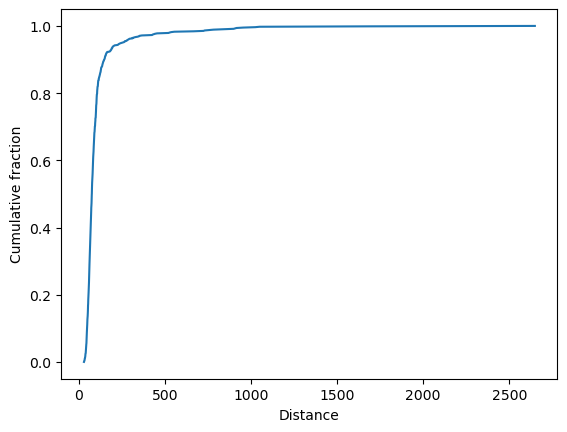

In [14]:
import numpy as np

d = np.sort(df["Neighbors_FirstClosestDistance_Expanded"])

plt.plot(d, np.linspace(0,1,len(d)))
plt.xlabel("Distance")
plt.ylabel("Cumulative fraction")
plt.show()

In [16]:
df["Neighbors_FirstClosestDistance_Expanded"].median() * 1.5

np.float64(112.04534870019597)

In [35]:
import networkx as nx

G = nx.Graph()

# add all cells
G.add_nodes_from(df.index)

max_dist = 50

for i, row in df.iterrows():

    j1 = int(row["Neighbors_FirstClosestObjectNumber_Expanded"]) - 1
    d1 = row["Neighbors_FirstClosestDistance_Expanded"]

    if j1 >= 0 and d1 < max_dist:
        G.add_edge(i, j1)

    j2 = int(row["Neighbors_SecondClosestObjectNumber_Expanded"]) - 1
    d2 = row["Neighbors_SecondClosestDistance_Expanded"]

    if j2 >= 0 and d2 < max_dist:
        G.add_edge(i, j2)

components = list(nx.connected_components(G))

colony_id = {}
for k, comp in enumerate(components):
    for idx in comp:
        colony_id[idx] = k

df["colony_id_graph"] = df.index.map(colony_id)


In [43]:
from sklearn.neighbors import NearestNeighbors

coords = results_fullslide[["nucleus_i","nucleus_j"]].values

nbrs = NearestNeighbors(radius=150).fit(coords)
neighbors = nbrs.radius_neighbors(coords, return_distance=False)

G = nx.Graph()
G.add_nodes_from(range(len(df)))

for i, neighs in enumerate(neighbors):
    for j in neighs:
        if i != j:
            G.add_edge(i, j)

components = list(nx.connected_components(G))

colony_id = {}
for k, comp in enumerate(components):
    for idx in comp:
        colony_id[idx] = k

results_fullslide["colony_id_graph"] = df.index.map(colony_id)

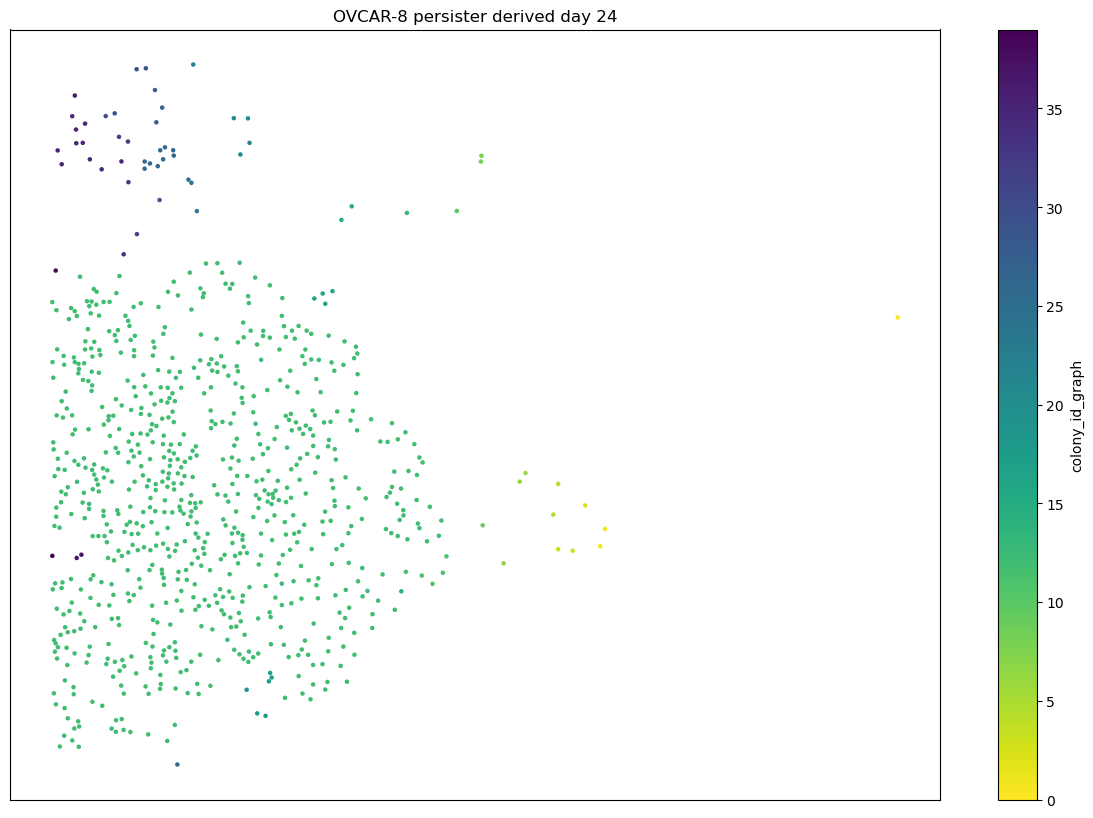

In [48]:
plt.figure(figsize=(15,10))

plt.scatter(
    results_fullslide["nucleus_i"],
    results_fullslide["nucleus_j"],
    c=results_fullslide["colony_id_graph"],
    s=5,
    cmap="viridis_r"
)
plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.colorbar(label="colony_id_graph")
plt.title("OVCAR-8 persister derived day 24")

plt.gca().invert_xaxis()
plt.show()

In [13]:
# log = "/Users/hannahbolen/Desktop/image_analysis/whole_slide/deeptile_implement/log.txt"
# with open(log, 'a') as f:
#     f.write(
#         f"Processing o8n_1gray_s20.ome.tif on macbook. Image stored on cluster, accessed with ~server_mount\n" \
#         f"Time to segment nuclei with cellpose: {(finish_segment_nuclei-start_cellpose):.2f} s\n" \
#         f"Time to save nuclei mask to ~server_mount: {(save_nuclei_mask-finish_segment_nuclei):.2f} s\n" \
#         f"Time to load and tile foci channel: {(start_seg_foci-save_nuclei_mask):.2f} s\n" \
#         f"Time to segment foci: {(finish_seg_foci-start_seg_foci):.2f} s\n" \
#         f"Time to save foci mask to ~server_mount: {(start_feature_extract-finish_seg_foci):.2f} s\n" \
#         f"Time to extract features: {(finish_feature_extract-start_feature_extract):.2f} s\n" \
#         )

In [14]:
# print(
#         f"Processing o8n_1gray_s20.ome.tif on macbook. Image stored on cluster, accessed with ~server_mount\n" \
#         f"Time to segment nuclei with cellpose: {(finish_segment_nuclei-start_cellpose):.2f} s\n" \
#         f"Time to save nuclei mask to ~server_mount: {(save_nuclei_mask-finish_segment_nuclei):.2f} s\n" \
#         f"Time to load and tile foci channel: {(start_seg_foci-save_nuclei_mask):.2f} s\n" \
#         f"Time to segment foci: {(finish_seg_foci-start_seg_foci):.2f} s\n" \
#         f"Time to save foci mask to ~server_mount: {(start_feature_extract-finish_seg_foci):.2f} s\n" \
#         f"Time to extract features: {(finish_feature_extract-start_feature_extract):.2f} s\n" \
# )